In [27]:
import torch
import numpy as np
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.multiprocessing as mp

# 1. 禁用 Windows 错误对话框
if sys.platform == 'win32':
    kernel32 = ctypes.WinDLL('kernel32')
    kernel32.SetErrorMode(0x0001 | 0x0002)  # SEM_FAILCRITICALERRORS | SEM_NOGPFAULTERRORBOX

# 2. 设置多进程启动方法
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass



class DiabetesDataset(Dataset):
    def __init__(self,filepath):
        super().__init__()
        xy = np.loadtxt(filepath,delimiter=',',dtype=np.float32)
        self.len =xy.shape[0]
        self.x_data = torch.from_numpy(xy[:,:-1])
        self.y_data = torch.from_numpy(xy[:,[-1]])
    def __getitem__(self, index):   #the expression,dataset[index],will call this magic function
      return self.x_data[index],self.y_data[index]
    def __len__(self):   #this magic function returns length of dataset
        return self.len
    #dataloader initializer loader with batch-size,shuffle,process number
    #  num_workers=2#多线程
dataset = DiabetesDataset('diabetes.csv.gz')
train_loader = DataLoader(dataset=dataset,  batch_size=32,shuffle=True, num_workers=0)

                          
# 构建模型
class Model(torch.nn.Module):
    def __init__(self):
        super(Model,self).__init__()
        self.linear1 = torch.nn.Linear(8,6)
        self.linear2 = torch.nn.Linear(6,4)
        self.linear3 = torch.nn.Linear(4,1)
        self.sigmoid = torch.nn.Sigmoid()
    def forward(self,x):
        x = self.sigmoid(self.linear1(x))
        x= self.sigmoid(self.linear2(x))
        x = self.sigmoid(self.linear3(x))
        
        return x
                         
model = Model()

# 构建损失函数与优化器

criterion = torch.nn.BCELoss(size_average=False)

optimizer = torch.optim.SGD(model.parameters(),lr=0.001)


 
                          
# the implementation of multiprocessing is different on windows,which uses spawn instead of fork
# so we have to wrap the code with an if-clause to protect the code from executon multiple tmes
if __name__ == '__main__':
    for epoch in range(3000):
        for i,data in enumerate(train_loader,0):
            # 1.prepare data 
            inputs,labels =data
            #forward 
            y_pred = model(inputs)
            loss = criterion(y_pred,labels)
            print(epoch,i,loss.item())
            optimizer.zero_grad()
            loss.backward()
            # update
            optimizer.step()
# train_dataset = datasets.MNIST(root='../dataset/mnist')
    # 在训练循环后添加
    torch.save(model.state_dict(), 'diabetes_model')
    print("Model saved!")



#training cycle
# definiton :one forward pass and one backward pass of the the training examples
# batch-size :the number of training examples in one forward backward pass
# ilteration (迭代): number of passes,each pass using (batch size) number of examples
# for epoch in range (training_epochs):
#     #LOOP循环 over all batches
#     for i in range(total_batch):
        

0 0 21.408517837524414
0 1 21.932130813598633
0 2 21.137184143066406
0 3 20.016864776611328
0 4 20.531776428222656
0 5 21.95834732055664
0 6 21.964393615722656
0 7 21.658676147460938
0 8 20.773639678955078
0 9 21.959226608276367
0 10 20.746150970458984
0 11 20.413787841796875
0 12 20.67286491394043
0 13 20.98145866394043
0 14 20.980819702148438
0 15 22.295166015625
0 16 19.642284393310547
0 17 19.905790328979492
0 18 23.058427810668945
0 19 20.593608856201172
0 20 20.567110061645508
0 21 20.555747985839844
0 22 21.253419876098633
0 23 13.949466705322266
1 0 21.24090576171875
1 1 21.64458656311035
1 2 21.249149322509766
1 3 21.621156692504883
1 4 18.965770721435547
1 5 21.252628326416016
1 6 22.03106689453125
1 7 20.85214614868164
1 8 20.831148147583008
1 9 21.225526809692383
1 10 22.44386863708496
1 11 20.022933959960938
1 12 21.22740936279297
1 13 19.997879028320312
1 14 19.9771671295166
1 15 20.782819747924805
1 16 19.926557540893555
1 17 21.632535934448242
1 18 21.200275421142578
1 

In [ ]:
# print(list(train_loader))

[[tensor([[-0.7647,  0.1558,  0.0492, -0.5556,  0.0000, -0.0820, -0.7071,  0.0000],
        [-0.7647,  0.3467,  0.1475,  0.0000,  0.0000, -0.1386, -0.6038, -0.9333],
        [-0.4118, -0.0352,  0.2131, -0.6364, -0.8416,  0.0015, -0.2152, -0.2667],
        [-0.6471,  0.2060,  0.1475, -0.3939, -0.6809,  0.2787, -0.6806, -0.7000],
        [-0.4118, -0.1357,  0.1148, -0.4343, -0.8322, -0.0999, -0.7558, -0.9000],
        [-0.4118,  0.0553,  0.1803, -0.4141, -0.2317,  0.0999, -0.9308, -0.7667],
        [ 0.0000,  0.1960,  0.0492, -0.6364, -0.7825,  0.0402, -0.4475, -0.9333],
        [ 0.0000,  0.2362,  0.4426, -0.2525,  0.0000,  0.0492, -0.8984, -0.7333],
        [-0.6471, -0.1055,  0.2131, -0.6768, -0.7991, -0.0939, -0.5961, -0.4333],
        [-0.7647, -0.1256,  0.0000, -0.5354,  0.0000, -0.1386, -0.4065, -0.8667],
        [-0.4118,  0.2663,  0.2787, -0.4545, -0.9480, -0.1177, -0.6917, -0.3667],
        [ 0.1765,  0.2261,  0.1148,  0.0000,  0.0000, -0.0700, -0.8463, -0.3333],
        [-0.88

In [ ]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import sys
# import ctypes
# import torch.multiprocessing as mp
# from sklearn.preprocessing import StandardScaler

# # 1. 禁用 Windows 错误对话框
# if sys.platform == 'win32':
#     kernel32 = ctypes.WinDLL('kernel32')
#     kernel32.SetErrorMode(0x0001 | 0x0002)  # SEM_FAILCRITICALERRORS | SEM_NOGPFAULTERRORBOX

# # 2. 设置多进程启动方法
# try:
#     mp.set_start_method('spawn', force=True)
# except RuntimeError:
#     pass

# # 3. 数据标准化 (关键步骤!)
# xy = np.loadtxt('diabetes.csv.gz', delimiter=',', dtype=np.float32)
# x_data = xy[:, :-1]
# y_data = xy[:, [-1]]

# # 标准化特征数据
# scaler = StandardScaler()
# x_data = scaler.fit_transform(x_data)

# class DiabetesDataset(Dataset):
#     def __init__(self, x_data, y_data):
#         super().__init__()
#         self.x_data = torch.from_numpy(x_data).float()
#         self.y_data = torch.from_numpy(y_data).float()
#         self.len = len(x_data)
        
#     def __getitem__(self, index):
#         return self.x_data[index], self.y_data[index]
    
#     def __len__(self):
#         return self.len

# # 创建标准化后的数据集
# dataset = DiabetesDataset(x_data, y_data)
# train_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True, num_workers=0)

# # 4. 定义模型并改进模型结构
# class DiabetesModel(nn.Module):
#     def __init__(self):
#         super(DiabetesModel, self).__init__()
#         self.linear1 = nn.Linear(8, 16)
#         self.linear2 = nn.Linear(16, 8)
#         self.linear3 = nn.Linear(8, 4)
#         self.linear4 = nn.Linear(4,1)  #并不是出层数越多越好
#         self.relu = nn.ReLU()  # 使用ReLU替代Sigmoid解决梯度消失
#         self.dropout = nn.Dropout(0.3)  # 添加Dropout防止过拟合
        
#     def forward(self, x):
#         x = self.relu(self.linear1(x))
#         x = self.dropout(x)
#         x = self.relu(self.linear2(x))
#         x = self.dropout(x)
#         x = self.linear3(x) 
#         x = self.relu(x)
#         x = self.dropout(x)
#         x = self.linear4(x)      # 最后一层不使用激活函数
#         return x

# model = DiabetesModel()

# # 5. 使用更合适的损失函数和优化器
# criterion = nn.BCEWithLogitsLoss()  # 比BCELoss更稳定，包含sigmoid
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # 自适应学习率

# # 6. 添加学习率调度器
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=10, verbose=True
# )

# if __name__ == '__main__':
#     # 7. 训练循环优化
#     best_loss = float('inf')
#     early_stop_counter = 0
    
#     for epoch in range(1000):
#         epoch_loss = 0.0
#         model.train()
        
#         for i, (inputs, labels) in enumerate(train_loader):
#             # 前向传播
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             epoch_loss += loss.item() * inputs.size(0)
            
#             # 反向传播和优化
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
            
#             # 每50个批次打印一次
#             if i % 50 == 0:
#                 print(f'Epoch: {epoch}, Batch: {i}, Loss: {loss.item():.4f}')
        
#         # 计算平均epoch损失
#         epoch_loss /= len(dataset)
        
#         # 更新学习率
#         scheduler.step(epoch_loss)
        
#         # 打印epoch损失
#         print(f'Epoch: {epoch}, Avg Loss: {epoch_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
#         # 8. 提前停止和模型保存
#         if epoch_loss < best_loss:
#             best_loss = epoch_loss
#             early_stop_counter = 0
#             torch.save(model.state_dict(), 'best_diabetes_model.pth')
#             print(f"保存最佳模型，损失: {best_loss:.4f}")
#         else:
#             early_stop_counter += 1
#             if early_stop_counter >= 20:  # 20个epoch损失未改善则停止
#                 print(f"提前停止，最佳损失: {best_loss:.4f}")
#                 break
    
#     # 9. 加载最佳模型并评估
#     model.load_state_dict(torch.load('best_diabetes_model.pth'))
#     model.eval()
#     with torch.no_grad():
#         outputs = model(dataset.x_data)
#         predicted = torch.sigmoid(outputs) > 0.5
#         correct = (predicted.float() == dataset.y_data).sum().item()
#         accuracy = correct / len(dataset) * 100
#         final_loss = criterion(outputs, dataset.y_data).item()
        
#         print(f"最终损失值: {final_loss:.4f}")
#         print(f"训练集准确率: {accuracy:.2f}%")
    
#     print("训练完成!")
    

d:\Users\zyl\anaconda3\envs\pytorchgpu\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch: 0, Batch: 0, Loss: 0.7064
Epoch: 0, Avg Loss: 0.7054, LR: 0.001000
保存最佳模型，损失: 0.7054
Epoch: 1, Batch: 0, Loss: 0.6950
Epoch: 1, Avg Loss: 0.6962, LR: 0.001000
保存最佳模型，损失: 0.6962
Epoch: 2, Batch: 0, Loss: 0.6728
Epoch: 2, Avg Loss: 0.6859, LR: 0.001000
保存最佳模型，损失: 0.6859
Epoch: 3, Batch: 0, Loss: 0.6785
Epoch: 3, Avg Loss: 0.6615, LR: 0.001000
保存最佳模型，损失: 0.6615
Epoch: 4, Batch: 0, Loss: 0.6611
Epoch: 4, Avg Loss: 0.6456, LR: 0.001000
保存最佳模型，损失: 0.6456
Epoch: 5, Batch: 0, Loss: 0.6155
Epoch: 5, Avg Loss: 0.6235, LR: 0.001000
保存最佳模型，损失: 0.6235
Epoch: 6, Batch: 0, Loss: 0.6199
Epoch: 6, Avg Loss: 0.5980, LR: 0.001000
保存最佳模型，损失: 0.5980
Epoch: 7, Batch: 0, Loss: 0.7010
Epoch: 7, Avg Loss: 0.5849, LR: 0.001000
保存最佳模型，损失: 0.5849
Epoch: 8, Batch: 0, Loss: 0.6577
Epoch: 8, Avg Loss: 0.5797, LR: 0.001000
保存最佳模型，损失: 0.5797
Epoch: 9, Batch: 0, Loss: 0.6748
Epoch: 9, Avg Loss: 0.5696, LR: 0.001000
保存最佳模型，损失: 0.5696
Epoch: 10, Batch: 0, Loss: 0.6271
Epoch: 10, Avg Loss: 0.5613, LR: 0.001000
保存最佳

C:\Users\zyl\AppData\Local\Temp\ipykernel_65812\1299769022.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_diabetes_model.pth'))

#Mnist Datase

In [ ]:
# Logits 是深度学习中一个重要的概念，通常指的是神经网络最后一层（如全连接层）产生的原始输出值。
# 它们可以被视为模型对输入数据的预测结果，表示每个类别的得分或置信度。
# 在多分类问题中，logits 表示每个类别的得分，而在二分类问题中，logits 则表示样本属于正类或负类的得分。
# logits 通常在经过 softmax 或 sigmoid 等激活函数处理后，转化为概率分布，以便进行分类任务

# 如果不使用激活函数，神经网络层与层之间的输出将是线性的组合，等效于单一的线性模型。无论网络多么深，最终的输出都是输入的线性变换，无法解决复杂的模式识别问题。
# 因此，激活函数引入了非线性，使神经网络能够拟合复杂的高维数据。

# 引入非线性：神经网络通过激活函数引入非线性，能够拟合复杂的非线性函数，解决复杂问题。

# 保证梯度传播：通过适当的激活函数可以使得梯度能够良好地反向传播，从而有效地进行参数更新。

# 特征压缩与选择：激活函数通常可以对输入信号进行压缩，抑制不重要的信号并突出关键的特征。

#下载数据集

下载 train-images-idx3-ubyte.gz...
解压 train-images-idx3-ubyte.gz...
下载 train-labels-idx1-ubyte.gz...
解压 train-labels-idx1-ubyte.gz...
下载 t10k-images-idx3-ubyte.gz...
解压 t10k-images-idx3-ubyte.gz...
下载 t10k-labels-idx1-ubyte.gz...
解压 t10k-labels-idx1-ubyte.gz...


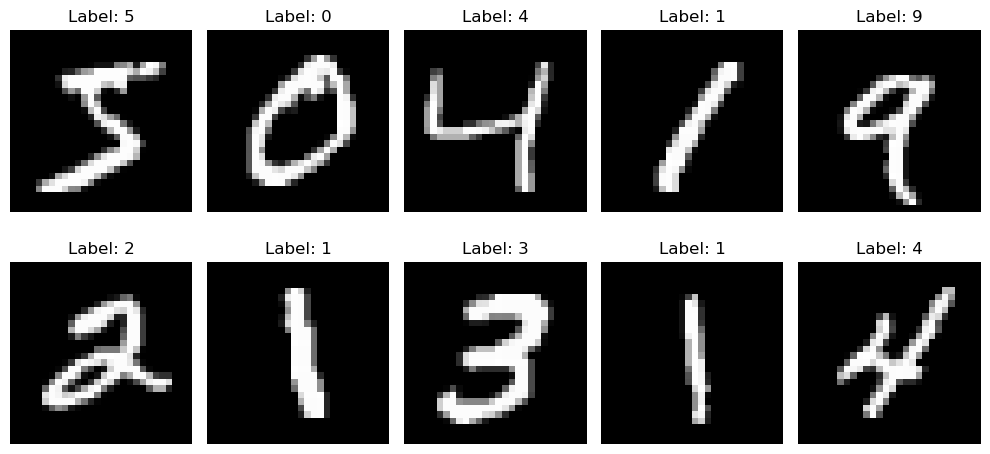

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import requests
import gzip
import shutil

# ===== 1. 确保数据集存在 =====
def ensure_mnist_exists():
    # 创建正确的目录结构
    data_dir = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data', 'MNIST', 'raw')
    os.makedirs(data_dir, exist_ok=True)
    
    # 需要下载的文件列表
    files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]
    
    base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"
    
    for file in files:
        file_path = os.path.join(data_dir, file)
        extracted_path = file_path.replace('.gz', '')
        
        # 如果文件已存在则跳过
        if os.path.exists(extracted_path):
            continue
            
        # 下载文件
        print(f"下载 {file}...")
        response = requests.get(base_url + file)
        with open(file_path, 'wb') as f:
            f.write(response.content)
        
        # 解压文件
        print(f"解压 {file}...")
        with gzip.open(file_path, 'rb') as f_in:
            with open(extracted_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        
        # 删除压缩文件（可选）
        os.remove(file_path)

# 确保数据集存在
ensure_mnist_exists()

# ===== 2. 创建数据集加载器 =====
# 正确的数据路径
data_path = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data')

# 修正Normalize参数格式
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 注意这里是元组 (0.5,)
])

# 使用正确的数据集名称和参数语法
trainset = datasets.MNIST(  # 修正：MNIST 不是 WMIST
    data_path, 
    download=False,         # 修正：download=False 不是 download-False
    train=True, 
    transform=transform     # 修正：transform=transform 不是 transforms-transform
)

testset = datasets.MNIST(   # 修正：MNIST 不是 WMIST
    data_path, 
    download=False,         # 修正：download=False 不是 download-False
    train=False, 
    transform=transform     # 修正：transform=transform 不是 transforms-transform
)

# ===== 3. 可视化 =====
n = 10
plt.figure(figsize=(10, 5))
for i in range(n):
    image, label = trainset[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(image.squeeze().numpy(), cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [48]:
import torch 
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
import torch.nn.functional as F
import torch.optim as optim
batch_size = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))   #the parameters mean and std respectively. it use formulation below
])
# 加载数据'.pytorch\MNIST_data'

train_loader = DataLoader(dataset=trainset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(dataset=testset,shuffle=False,batch_size=batch_size)


# 构造模型
class Net(torch.nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.linear1 = torch.nn.Linear(784,512)
        self.linear2 = torch.nn.Linear(512,256)
        self.linear3 = torch.nn.Linear(256,128)
        self.linear4 = torch.nn.Linear(128,64)
        self.linear5 = torch.nn.Linear(64,10)
        self.dropout = torch.nn.Dropout(0.3)
    def forward(self,x):
        x = x.view(-1,784)
        x = F.relu(self.linear1(x))
        x= self.dropout(x)
        x = F.relu(self.linear2(x))
        x = self.dropout(x)
        x = F.relu(self.linear3(x))
        x = self.dropout(x)
        x = F.relu(self.linear4(x))
        x = self.dropout(x)
        x = self.linear5(x)
        return x
    


model = Net()
# 初始化模型和优化器
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# model = Net().to(device)




# 构造优化器与模型损失函数
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=0.01,momentum=0.5)

# . 添加学习率调度器
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#      optimizer, mode='min', factor=0.5, patience=10, verbose=True
#  )

def train(epoch):
   
    running_loss =0
    for batch_idx ,data in enumerate(train_loader,0):
        inputs,target =data
        outputs = model(inputs)
        optimizer.zero_grad()
        loss = criterion(outputs,target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 300 ==299:
            print('[%d,%5d] loss:%.3f' % (epoch+1,batch_idx+1 ,running_loss/300))
            running_loss=0.0

def test():
   
    correct = 0
    total = 0
    with torch.no_grad():
        for data  in test_loader:
            images , labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data,dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print("accuracy on test set: %d%%"  % (100*correct/total))



if __name__ == '__main__':
    for epoch in range(20):
      
        train(epoch)
        test()
        
       )

[1,  300] loss:2.290
[1,  600] loss:2.043
[1,  900] loss:1.209
accuracy on test set: 68%
[2,  300] loss:0.802
[2,  600] loss:0.635
[2,  900] loss:0.548
accuracy on test set: 85%
[3,  300] loss:0.460
[3,  600] loss:0.424
[3,  900] loss:0.380
accuracy on test set: 90%
[4,  300] loss:0.347
[4,  600] loss:0.318
[4,  900] loss:0.304
accuracy on test set: 92%
[5,  300] loss:0.270
[5,  600] loss:0.254
[5,  900] loss:0.252
accuracy on test set: 93%
[6,  300] loss:0.226
[6,  600] loss:0.226
[6,  900] loss:0.224
accuracy on test set: 94%
[7,  300] loss:0.207
[7,  600] loss:0.197
[7,  900] loss:0.187
accuracy on test set: 94%
[8,  300] loss:0.182
[8,  600] loss:0.182
[8,  900] loss:0.173
accuracy on test set: 95%
[9,  300] loss:0.167
[9,  600] loss:0.154
[9,  900] loss:0.165
accuracy on test set: 95%
[10,  300] loss:0.148
[10,  600] loss:0.153
[10,  900] loss:0.152
accuracy on test set: 95%
[11,  300] loss:0.135
[11,  600] loss:0.142
[11,  900] loss:0.136
accuracy on test set: 95%
[12,  300] loss

#Ai代码

In [ ]:
import torch 
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn

# 1. 设置超参数
batch_size = 64

# 2. 定义数据转换
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # 修正逗号位置
])

# 3. 加载数据集 - 添加缺失的MNIST数据集定义
# 创建数据目录
import os
data_path = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data')
os.makedirs(data_path, exist_ok=True)

# 下载数据集
trainset = datasets.MNIST(
    data_path, 
    download=True, 
    train=True, 
    transform=transform
)

testset = datasets.MNIST(
    data_path, 
    download=True, 
    train=False, 
    transform=transform
)

# 4. 创建数据加载器
train_loader = DataLoader(
    dataset=trainset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    dataset=testset, 
    shuffle=False, 
    batch_size=batch_size
)

# 5. 构造模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, 256)
        self.linear3 = nn.Linear(256, 128)
        self.linear4 = nn.Linear(128, 64)
        self.linear5 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = x.view(-1, 784)  # 展平图像
        x = F.relu(self.linear1(x))
        x = self.dropout(x)
        x = F.relu(self.linear2(x))
        x = self.dropout(x)
        x = F.relu(self.linear3(x))
        x = self.dropout(x)
        x = F.relu(self.linear4(x))
        x = self.dropout(x)
        x = self.linear5(x)  # 最后一层不需要激活函数
        return x

# 6. 初始化模型和优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = Net().to(device)

# 7. 构造优化器与损失函数
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 降低学习率

# 8. 添加学习率调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# 9. 训练函数
def train(epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, targets = data
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 修正输入变量名 (inputs 不是 input)
        outputs = model(inputs)
        
        optimizer.zero_grad()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 100 == 99:  # 每100个batch打印一次
            print(f'[{epoch+1}, {batch_idx+1:5d}] loss: {running_loss/100:.3f}')
            running_loss = 0.0
    
    return loss.item()  # 返回最后一个批次的损失用于调度器

# 10. 测试函数
def test():
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            test_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = test_loss / len(test_loader)
    print(f"Accuracy on test set: {accuracy:.2f}%, Loss: {avg_loss:.4f}")
    return avg_loss

# 11. 主训练循环
if __name__ == '__main__':
    for epoch in range(10):
        print(f"\nEpoch {epoch+1}/10")
        train_loss = train(epoch)
        test_loss = test()
        
        # 根据测试损失更新学习率
        scheduler.step(test_loss)
        
    print("Finished Training")

In [32]:
import os
print("检查本地MNIST文件:")
print(os.listdir(r'D:\机器学习与深度学习\pythonlearn_zfx\MNIST'))
# 应显示4个文件:
# ['t10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz', 
#  'train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz']

检查本地MNIST文件:
['t10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz', 'train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz']
